# Fine grained tool calling (with streaming events)

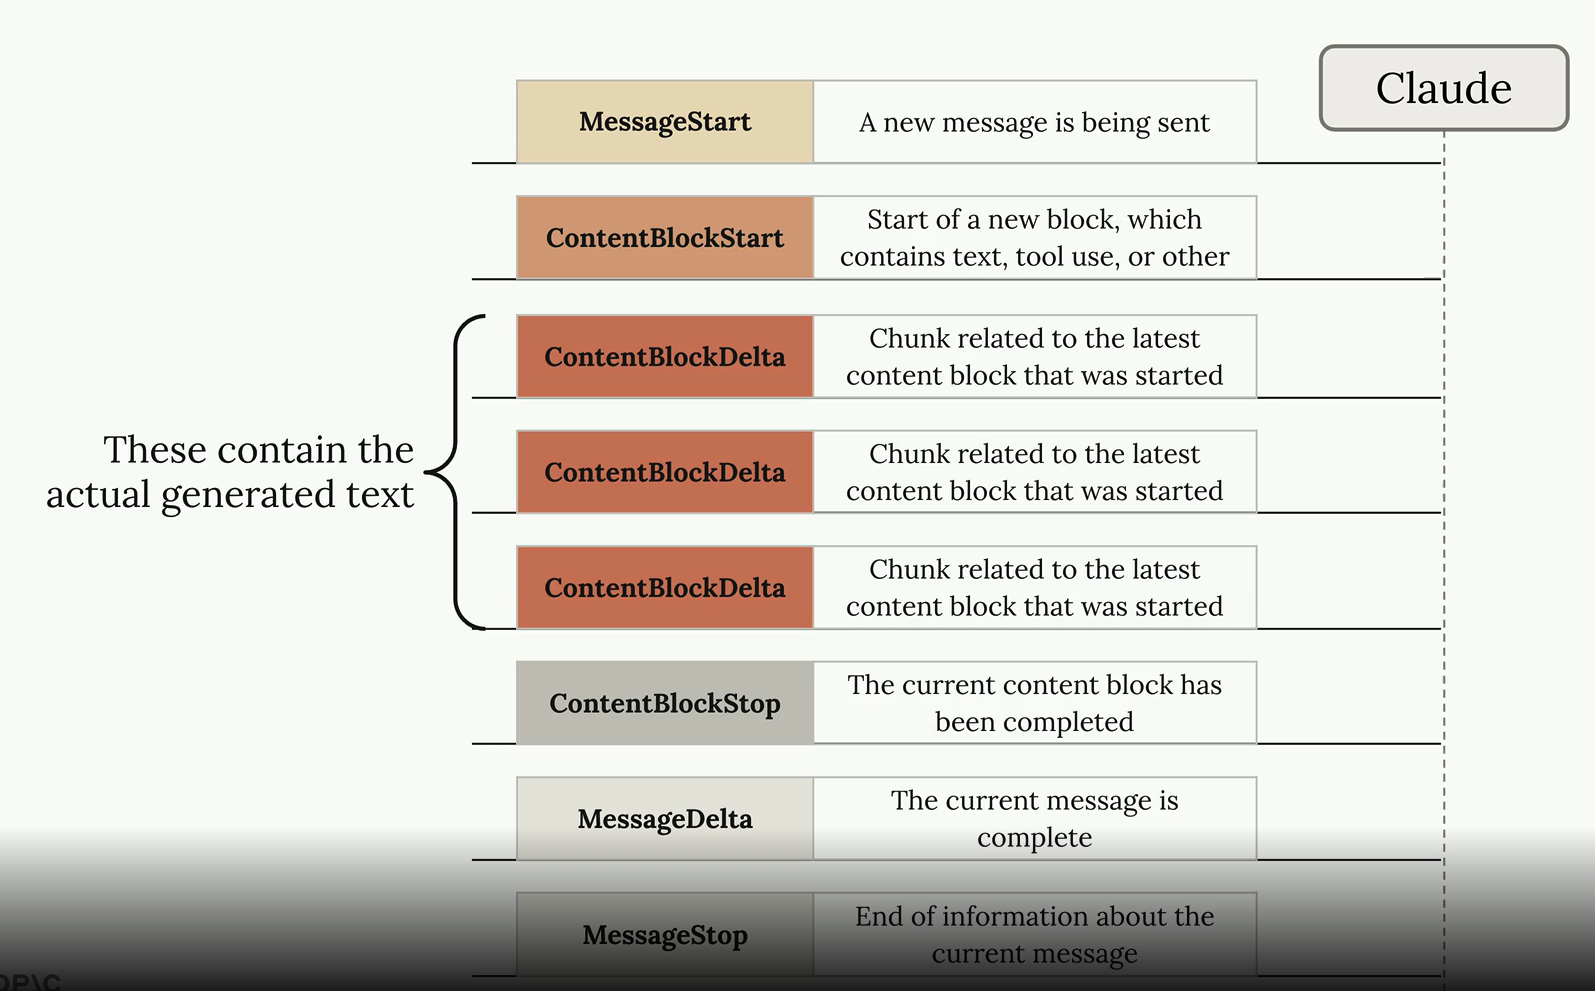

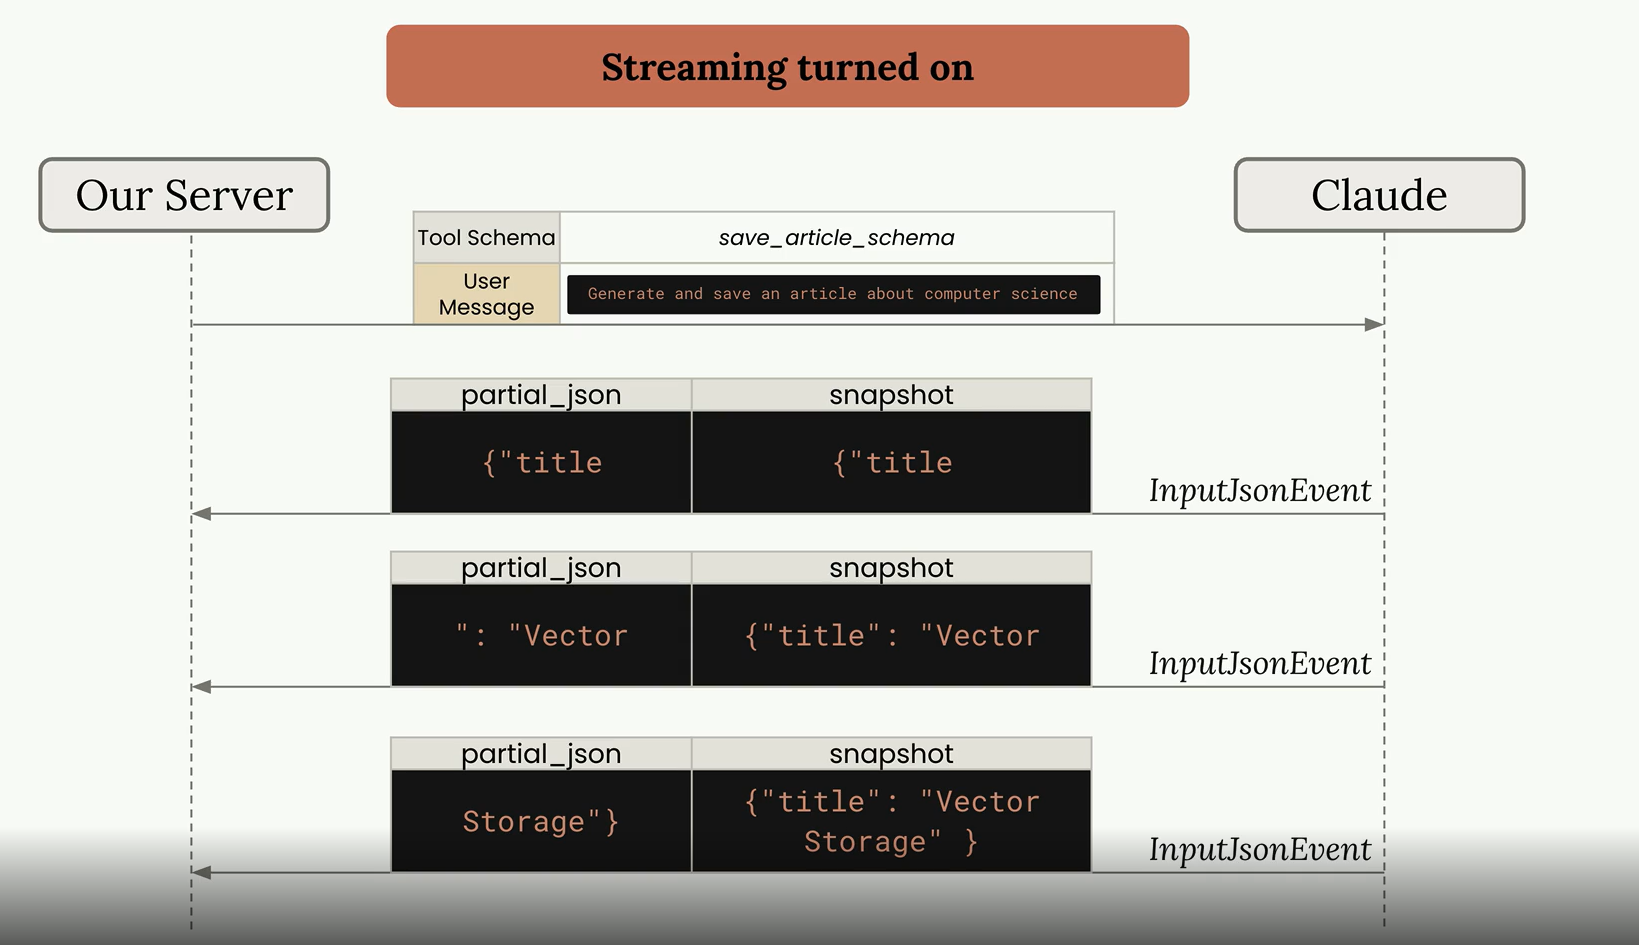

This notebook has been directly downloaded from the lesson, this is not my code.

We will work on this notebook for this lesson

Even if streaming, Claude validates each json piece before sending them back. This adds some latency and if you don't want this, you can enable **fine grained tool calling, which disables the Claude-side json validation before sending the chunk back**

In [1]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic


load_dotenv()

client = Anthropic()
model = "claude-sonnet-4-5"

In [2]:
# Helper functions


def add_user_message(messages, message):
    if isinstance(message, list):
        user_message = {
            "role": "user",
            "content": message,
        }
    else:
        user_message = {
            "role": "user",
            "content": [{"type": "text", "text": message}],
        }
    messages.append(user_message)


def add_assistant_message(messages, message):
    if isinstance(message, list):
        assistant_message = {
            "role": "assistant",
            "content": message,
        }
    elif hasattr(message, "content"):
        content_list = []
        for block in message.content:
            if block.type == "text":
                content_list.append({"type": "text", "text": block.text})
            elif block.type == "tool_use":
                content_list.append(
                    {
                        "type": "tool_use",
                        "id": block.id,
                        "name": block.name,
                        "input": block.input,
                    }
                )
        assistant_message = {
            "role": "assistant",
            "content": content_list,
        }
    else:
        # String messages need to be wrapped in a list with text block
        assistant_message = {
            "role": "assistant",
            "content": [{"type": "text", "text": message}],
        }
    messages.append(assistant_message)


def chat_stream(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    tool_choice=None,
    betas=[],
):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if tool_choice:
        params["tool_choice"] = tool_choice

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    if betas:
        params["betas"] = betas

    return client.beta.messages.stream(**params)


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])

In [3]:
# Tool definition
from anthropic.types import ToolParam

save_article_schema = ToolParam(
    {
        "name": "save_article",
        "description": "Saves a scholarly journal article",
        "input_schema": {
            "type": "object",
            "properties": {
                "abstract": {
                    "type": "string",
                    "description": "Abstract of the article. One short sentence max",
                },
                "meta": {
                    "type": "object",
                    "properties": {
                        "word_count": {
                            "type": "integer",
                            "description": "Word count",
                        },
                        "review": {
                            "type": "string",
                            "description": "Eight sentence review of the paper",
                        },
                    },
                    "required": ["word_count", "review"],
                },
            },
            "required": ["abstract", "meta"],
        },
    }
)
save_short_article_schema = ToolParam(
    {
        "name": "save_article",
        "description": "Saves a scholarly journal article",
        "input_schema": {
            "type": "object",
            "properties": {
                "abstract": {
                    "type": "string",
                    "description": "Abstract of the article. One short sentence max",
                },
                "meta": {
                    "type": "object",
                    "properties": {
                        "word_count": {
                            "type": "integer",
                            "description": "Word count",
                        },
                        "review": {
                            "type": "string",
                            "description": "Review of paper. One short sentence max",
                        },
                    },
                    "required": ["word_count", "review"],
                },
            },
            "required": ["abstract", "meta"],
        },
    }
)


def save_article(**kwargs):
    return "Article saved!"


In [4]:
# Tool Running
import json


def run_tool(tool_name, tool_input):
    if tool_name == "save_article":
        return save_article(**tool_input)


def run_tools(message):
    tool_requests = [block for block in message.content if block.type == "tool_use"]
    tool_result_blocks = []

    for tool_request in tool_requests:
        try:
            tool_output = run_tool(tool_request.name, tool_request.input)
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": json.dumps(tool_output),
                "is_error": False,
            }
        except Exception as e:
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": f"Error: {e}",
                "is_error": True,
            }

        tool_result_blocks.append(tool_result_block)

    return tool_result_blocks

In [5]:
# Run conversation
def run_conversation(messages, tools=[], tool_choice=None, fine_grained=False):
    while True:
        with chat_stream(
            messages,
            tools=tools,
            betas=["fine-grained-tool-streaming-2025-05-14"] if fine_grained else [],
            tool_choice=tool_choice,
        ) as stream:
            for chunk in stream:
                if chunk.type == "text":
                    print(chunk.text, end="")

                if chunk.type == "content_block_start":
                    if chunk.content_block.type == "tool_use":
                        print(f'\n>>> Tool Call: "{chunk.content_block.name}"')

                if chunk.type == "input_json" and chunk.partial_json:
                    print(chunk.partial_json, end="")

                if chunk.type == "content_block_stop":
                    print("\n")

            response = stream.get_final_message()

        add_assistant_message(messages, response)

        if response.stop_reason != "tool_use":
            break

        tool_results = run_tools(response)
        add_user_message(messages, tool_results)

        if tool_choice:
            break

    return messages

In [7]:
messages = []

add_user_message(
    messages,
    "Create and save a fake computer science article",
)

run_conversation(
    messages,
    tools=[save_article_schema],
)

I'll create and save a fake computer science article for you.


>>> Tool Call: "save_article"
{"abstract": "This paper introduces a novel quantum-inspired algorithm for optimizing distributed neural network training across heterogeneous edge computing devices.", "meta": {"word_count":8547,"review":"This paper presents an innovative approach to distributed deep learning by leveraging quantum-inspired optimization techniques. The authors propose a hybrid algorithm that dynamically allocates computational resources across edge devices with varying capabilities. Experimental results demonstrate a 34% reduction in training time compared to traditional federated learning approaches. The theoretical framework is well-grounded in both quantum computing principles and distributed systems theory. However, the scalability analysis could benefit from larger-scale empirical validation. The paper makes significant contributions to the field of edge AI and distributed machine learning. Some implement

[{'role': 'user',
  'content': [{'type': 'text',
    'text': 'Create and save a fake computer science article'}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': "I'll create and save a fake computer science article for you."},
   {'type': 'tool_use',
    'id': 'toolu_01GLzVLLvDFBY9HZRa842i6h',
    'name': 'save_article',
    'input': {'abstract': 'This paper introduces a novel quantum-inspired algorithm for optimizing distributed neural network training across heterogeneous edge computing devices.',
     'meta': {'word_count': 8547,
      'review': 'This paper presents an innovative approach to distributed deep learning by leveraging quantum-inspired optimization techniques. The authors propose a hybrid algorithm that dynamically allocates computational resources across edge devices with varying capabilities. Experimental results demonstrate a 34% reduction in training time compared to traditional federated learning approaches. The theoretical framework is well-grou

In [9]:
# If we want more speed with the drawback of Claude not validating the JSON that sends us back, we can enable the fine_grained option
# YOU WILL HAVE TO IMPLEMENT CODE IN THE CLIENT SIDE TO VALIDATE THE JSON if you enable the fine_grained option
messages = []

add_user_message(
    messages,
    "Create and save a fake computer science article",
)

run_conversation(
    messages,
    tools=[save_article_schema],
    fine_grained=True
)

I'll create and save a fake computer science article for you.


>>> Tool Call: "save_article"
{"abstract": "This paper introduces a novel quantum-inspired algorithm for optimizing neural network architectures that achieves 47% faster training convergence on benchmark datasets.", "meta": {
  "word_count": 8742,
  "review": "This paper presents an innovative approach combining quantum computing principles with deep learning optimization. The authors propose a hybrid algorithm that leverages quantum annealing concepts to explore the neural architecture search space more efficiently. Experimental results demonstrate significant improvements in training time across multiple benchmark datasets including ImageNet and CIFAR-100. The theoretical foundation is well-established, building upon previous work in quantum machine learning. However, the practical applicability may be limited due to computational overhead in the quantum-inspired preprocessing phase. The paper would benefit from more ext

[{'role': 'user',
  'content': [{'type': 'text',
    'text': 'Create and save a fake computer science article'}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': "I'll create and save a fake computer science article for you."},
   {'type': 'tool_use',
    'id': 'toolu_01SVhvdocxngpHEDJiyv5BK5',
    'name': 'save_article',
    'input': {'abstract': 'This paper introduces a novel quantum-inspired algorithm for optimizing neural network architectures that achieves 47% faster training convergence on benchmark datasets.',
     'meta': {'word_count': 8742,
      'review': 'This paper presents an innovative approach combining quantum computing principles with deep learning optimization. The authors propose a hybrid algorithm that leverages quantum annealing concepts to explore the neural architecture search space more efficiently. Experimental results demonstrate significant improvements in training time across multiple benchmark datasets including ImageNet and CIFAR-100. T